#### 프로젝트 제출 루브릭

| 학습목표 | 평가기준 |
| --- | --- |
| SentencePiece를 이용하여 모델을 만들기까지의 과정이 정상적으로 진행되었는가? | 코퍼스 분석, 전처리, SentencePiece 적용, 토크나이저 구현 및 동작이 빠짐없이 진행되었는가?|
| SentencePiece를 통해 만든 Tokenizer가 자연어처리 모델과 결합하여 동작하는가? | SentencePiece 토크나이저가 적용된 Text Classifier 모델이 정상적으로 수렴하여 80% 이상의 test accuracy가 확인되었다. |
| SentencePiece의 성능을 다각도로 비교분석하였는가? | SentencePiece 토크나이저를 활용했을 때의 성능을 다른 토크나이저 혹은 SentencePiece의 다른 옵션의 경우와 비교하여 분석을 체계적으로 진행하였다. |

### 프로젝트 정리
```
# 이 구현은 앞 단계에서 만든 SentencePiece 토크나이저를 NSMC 리뷰에 적용
# 토큰 ID를 입력으로 하는 양방향 LSTM을 학습
# metrics의 test_accuracy와 위 그래프를 근거로 성능을 시각화
# 80% 기준을 만족하지 못하면 `EPOCHS`, `MAX_LENGTH`, `vocab_size`를 한 항목씩 바꿔 학습
```

### 프로젝트: SentencePiece 사용하기

In [39]:
import os
from pathlib import Path
import torch
from torch.nn.utils.rnn import pad_sequence
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import konlpy
import sentencepiece as spm

In [40]:
# Ablation Study를 위한 CONFIG 설정
CONFIG = {
    # 재현성 및 SentencePiece
    "seed": 42,
    "sentencepiece_vocab_size": 8000,
    "sentencepiece_model_type": "unigram",  # "unigram" 또는 "bpe"

    # 실행 모드 및 데이터
    "fast_run": False,  # 제출용은 False, 코드 점검용은 True
    "max_train_samples": None,
    "max_test_samples": None,
    "validation_ratio": 0.10,

    # LSTM 입력·구조
    "max_length": 80,
    "embedding_dim": 160,
    "hidden_dim": 160,
    "dropout": 0.35,

    # 학습
    "batch_size_cpu": 128,
    "batch_size_cuda": 256,
    "epochs": 8,
    "learning_rate": 1e-3,
    "weight_decay": 1e-4,
    "patience": 3,
    "gradient_clip_norm": 1.0,
    "rubric_accuracy": 0.80,

    # 토크나이저 비교: 동일한 NSMC train split에서 각 옵션을 새로 학습
    "run_tokenizer_comparison": True,
    "comparison_force_retrain": False,
    "comparison_epochs": 8,  # 공정 비교를 위해 기본 epochs와 같은 값 사용
    "comparison_options": [
        {"name": "unigram_8000", "model_type": "unigram", "vocab_size": 8000},
        {"name": "bpe_8000", "model_type": "bpe", "vocab_size": 8000},
        {"name": "unigram_4000", "model_type": "unigram", "vocab_size": 4000},
    ],
}

# 빠른 코드 점검용 설정
if CONFIG["fast_run"]:
    CONFIG.update({
        "max_train_samples": 20_000,
        "max_test_samples": 5_000,
        "epochs": 2,
        "sentencepiece_vocab_size": 4_000,
    })

CONFIG["batch_size"] = (
    CONFIG["batch_size_cuda"] if torch.cuda.is_available() else CONFIG["batch_size_cpu"]
)

print("[CONFIG]")
for key, value in CONFIG.items():
    print(f"{key}: {value}")

[CONFIG]
seed: 42
sentencepiece_vocab_size: 8000
sentencepiece_model_type: unigram
fast_run: False
max_train_samples: None
max_test_samples: None
validation_ratio: 0.1
max_length: 80
embedding_dim: 160
hidden_dim: 160
dropout: 0.35
batch_size_cpu: 128
batch_size_cuda: 256
epochs: 8
learning_rate: 0.001
weight_decay: 0.0001
patience: 3
gradient_clip_norm: 1.0
rubric_accuracy: 0.8
run_tokenizer_comparison: True
comparison_force_retrain: False
comparison_epochs: 8
comparison_options: [{'name': 'unigram_8000', 'model_type': 'unigram', 'vocab_size': 8000}, {'name': 'bpe_8000', 'model_type': 'bpe', 'vocab_size': 8000}, {'name': 'unigram_4000', 'model_type': 'unigram', 'vocab_size': 4000}]
batch_size: 256


In [41]:
print(f"PyTorch Version: {torch.__version__}")
print(f"NumPy Version: {np.__version__}")
print(f"Matplotlib Version: {matplotlib.__version__}")
print(f"Konlpy Version: {konlpy.__version__}")

PyTorch Version: 2.13.0+cu132
NumPy Version: 1.26.3
Matplotlib Version: 3.11.1
Konlpy Version: 0.6.0


#### Step 1. SentencePiece 설치하기

```
PS C:\Users\eaglesjo\Documents\GitHub\AIFFEL_quest_rs> pip install sentencepiece  
Collecting sentencepiece
  Downloading sentencepiece-0.2.2-cp311-cp311-win_amd64.whl.metadata (34 kB)
Downloading sentencepiece-0.2.2-cp311-cp311-win_amd64.whl (1.2 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 12.6 MB/s  0:00:00
Installing collected packages: sentencepiece
Successfully installed sentencepiece-0.2.2
```

In [42]:
# Data Preprocessing
# 기본적으로는 NSMC 데이터셋을 사용하지만, SentencePiece 모델 학습을 위해서는 한국어-영어 병렬 코퍼스를 사용합니다.
path_to_file = os.path.expanduser("~/work/sentiment_classification/data/korean-english-park.train.ko")

with open(path_to_file, "r", encoding="utf-8") as f:
    raw = f.read().splitlines()

min_len = 999
max_len = 0
sum_len = 0

for sen in raw:
    length = len(sen)
    if min_len > length: min_len = length
    if max_len < length: max_len = length
    sum_len += length

sentence_length = np.zeros((max_len), dtype=int)

for sen in raw:
    sentence_length[len(sen)-1] += 1

def check_sentence_with_length(raw, length):
    count = 0

    for sen in raw:
        if len(sen) == length:
            count += 1
            if count > 100: return

check_sentence_with_length(raw, 1)

cleaned_corpus = list(set(raw))  # set를 사용해서 중복을 제거합니다.

for sen in cleaned_corpus:
    length = len(sen)
    if min_len > length: min_len = length
    if max_len < length: max_len = length
    sum_len += length

sentence_length = np.zeros((max_len), dtype=int)

for sen in cleaned_corpus:   # 중복이 제거된 코퍼스 기준
    sentence_length[len(sen)-1] += 1

max_len = 150
min_len = 10

# 길이 조건에 맞는 문장만 선택합니다.
filtered_corpus = [s for s in cleaned_corpus if (len(s) < max_len) & (len(s) >= min_len)]

# 분포도를 다시 그려봅니다.
sentence_length = np.zeros((max_len), dtype=int)

for sen in filtered_corpus:
    sentence_length[len(sen)-1] += 1

#### Step 2. SentencePiece 모델 학습

In [43]:
class Tokenizer:
    def __init__(self, filters=''):
        self.word_index = {}
        self.index_word = {}
        self.filters = filters

    def fit_on_texts(self, corpus):
        for sentence in corpus:
            tokens = sentence.split() if isinstance(sentence, str) else sentence
            for token in tokens:
                if token not in self.word_index:
                    self.word_index[token] = len(self.word_index) + 1
        self.index_word = {idx: word for word, idx in self.word_index.items()}

    def texts_to_sequences(self, corpus):
        sequences = []
        for sentence in corpus:
            tokens = sentence.split() if isinstance(sentence, str) else sentence
            seq = [self.word_index.get(token, 0) for token in tokens]
            sequences.append(torch.tensor(seq, dtype=torch.long))
        return sequences

    def sequences_to_texts(self, sequences):
        texts = []
        for seq in sequences:
            if isinstance(seq, torch.Tensor):
                seq = seq.tolist()
            tokens = [self.index_word.get(idx, "") for idx in seq if idx != 0]
            texts.append(tokens)
        return texts

def tokenize(corpus):
    tokenizer = Tokenizer()
    tokenizer.fit_on_texts(corpus)
    sequences = tokenizer.texts_to_sequences(corpus)
    tensor = pad_sequence(sequences, batch_first=True, padding_value=0)
    return tensor, tokenizer

In [44]:
temp_file = Path.home() / "work" / "sentiment_classification" / "data" / "korean-english-park.train.ko.temp"

vocab_size = CONFIG["sentencepiece_vocab_size"]

# 학습용 텍스트 생성
with open(temp_file, 'w', encoding='utf-8') as f:
    for row in filtered_corpus:   # 이전에 나왔던 정제했던 corpus를 활용해서 진행해야 합니다.
        f.write(str(row) + '\n')

# SentencePiece 학습
spm.SentencePieceTrainer.Train(
    input = temp_file,
    model_prefix = Path.home() / "work" / "sentiment_classification" / "data" / "korean_spm",
    vocab_size = vocab_size,
    model_type = CONFIG["sentencepiece_model_type"]  # CONFIG에서 변경 가능
)

True

In [45]:
s = spm.SentencePieceProcessor()
s.Load(str(Path.home() / "work" / "sentiment_classification" / "data" / "korean_spm.model"))

# SentencePiece를 활용한 sentence -> encoding
tokensIDs = s.EncodeAsIds('아버지가방에들어가신다.')
print(tokensIDs)

# SentencePiece를 활용한 sentence -> encoded pieces
print(s.SampleEncodeAsPieces('아버지가방에들어가신다.',-1, 0.1))

# SentencePiece를 활용한 encoding -> sentence 복원
print(s.DecodeIds(tokensIDs))

[1202, 10, 318, 6, 3748, 10, 287, 31, 4]
['▁', '아버지', '가', '방', '에', '들', '어', '가', '신', '다', '.']
아버지가방에들어가신다.


#### Step 3. Tokenizer 함수 작성

In [46]:
def sp_tokenize(s, corpus):

    tensor = []

    for sen in corpus:
        tensor.append(s.EncodeAsIds(sen))

    with open("./korean_spm.vocab", 'r') as f:
        vocab = f.readlines()

    word_index = {}
    index_word = {}

    for idx, line in enumerate(vocab):
        word = line.split("\t")[0]

        word_index.update({word:idx})
        index_word.update({idx:word})

    tensor = pad_sequence(tensor, batch_first=True, padding_value=0)

    return tensor, word_index, index_word

#### Step 4. 네이버 영화리뷰 감정 분석 문제에 SentencePiece 적용해 보기


```
# korean_spm.model와 sp_tokenize()를 padding 가능한 torch.Tensor형태로 보완해 NSMC(네이버 영화리뷰) 데이터에 적용
# 모델은 SentencePiece 토큰 ID를 입력으로 받는 양방향 LSTM 분류기
# 학습 데이터에서만 모델 선택 SentencePiece 실험을 수행하고, validation으로 조기 종료를 판단한 뒤 마지막에 test set을 한 번만 평가
```


In [47]:
# !pip install -q pandas scikit-learn sentencepiece torch

import copy
import json
import random
import re
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from torch import nn
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence
from torch.utils.data import DataLoader, Dataset

SEED = CONFIG["seed"]
random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NSMC_DATA_DIR = Path(r"C:\Users\eaglesjo\work\sentiment_classification\data")

# 모든 실험 값은 CONFIG에서 관리
FAST_RUN = CONFIG["fast_run"]
MAX_TRAIN_SAMPLES = CONFIG["max_train_samples"]
MAX_TEST_SAMPLES = CONFIG["max_test_samples"]
MAX_LENGTH = CONFIG["max_length"]
BATCH_SIZE = CONFIG["batch_size"]
EPOCHS = CONFIG["epochs"]
LEARNING_RATE = CONFIG["learning_rate"]
PATIENCE = CONFIG["patience"]

print(f"Device: {DEVICE}")

Device: cuda


In [48]:
import matplotlib.font_manager as fm
font_path = r'C:\Windows\Fonts\NanumGothic.ttf'
fm.fontManager.addfont(font_path)
plt.rc('font', family='NanumGothic')

train=131,563, valid=14,619, test=49,157
       train  valid   test
label                     
부정(0)  66007   7335  24446
긍정(1)  65556   7284  24711


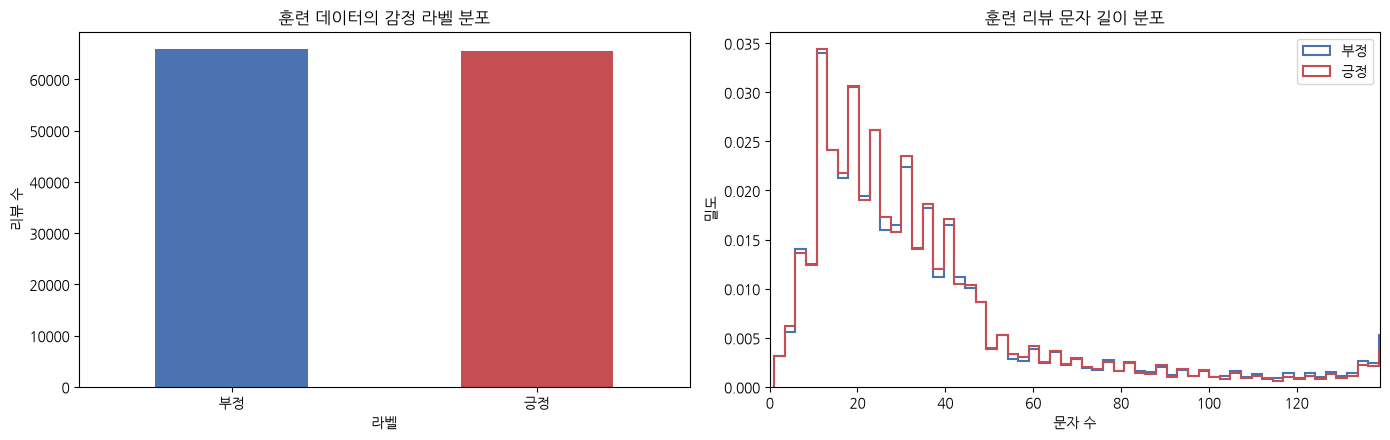

In [49]:
# NSMC 로딩·정제·분할 및 훈련 데이터 시각화
def clean_review(text: str) -> str:
    text = str(text).replace("\u200b", " ")
    text = re.sub(r"[\r\n\t]+", " ", text)
    return re.sub(r"\s+", " ", text).strip()

# NSMC 데이터셋 로딩 및 정제
def load_nsmc(filename: str, limit: int | None = None) -> pd.DataFrame:
    df = pd.read_csv(filename, sep="\t")
    df = df.dropna(subset=["document", "label"]).copy()
    df["document"] = df["document"].map(clean_review)
    df = df[df["document"].str.len() > 0]
    df["label"] = df["label"].astype(int)
    df = df.drop_duplicates(subset=["document"]).reset_index(drop=True)
    if limit is not None and limit < len(df):
        df, _ = train_test_split(df, train_size=limit, stratify=df["label"], random_state=SEED)
    df["char_length"] = df["document"].str.len()
    return df.reset_index(drop=True)

raw_train_df = load_nsmc("~/work/sentiment_classification/data/ratings_train.txt", MAX_TRAIN_SAMPLES)
test_df = load_nsmc("~/work/sentiment_classification/data/ratings_test.txt", MAX_TEST_SAMPLES)
train_df, valid_df = train_test_split(
    raw_train_df, test_size=CONFIG["validation_ratio"], stratify=raw_train_df["label"], random_state=SEED
)
train_df, valid_df = train_df.reset_index(drop=True), valid_df.reset_index(drop=True)

print(f"train={len(train_df):,}, valid={len(valid_df):,}, test={len(test_df):,}")
print(pd.concat({
    "train": train_df["label"].value_counts().sort_index(),
    "valid": valid_df["label"].value_counts().sort_index(),
    "test": test_df["label"].value_counts().sort_index(),
}, axis=1).rename(index={0: "부정(0)", 1: "긍정(1)"}))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
train_df["label"].map({0: "부정", 1: "긍정"}).value_counts().plot(
    kind="bar", color=["#4C72B0", "#C44E52"], ax=axes[0]
)
axes[0].set_title("훈련 데이터의 감정 라벨 분포")
axes[0].set_xlabel("라벨")
axes[0].set_ylabel("리뷰 수")
axes[0].tick_params(axis="x", rotation=0)

for label, color, name in [(0, "#4C72B0", "부정"), (1, "#C44E52", "긍정")]:
    axes[1].hist(
        train_df.loc[train_df.label == label, "char_length"], bins=60,
        density=True, histtype="step", linewidth=1.5, color=color, label=name
    )
axes[1].set_xlim(0, min(200, int(train_df.char_length.quantile(0.99))))
axes[1].set_title("훈련 리뷰 문자 길이 분포")
axes[1].set_xlabel("문자 수")
axes[1].set_ylabel("밀도")
axes[1].legend()
plt.tight_layout()
plt.show()

In [50]:
# SentencePiece 모델과 `sp_tokenize()` 재사용
# 생성한 korean_spm.model / korean_spm.vocab 사용
MODEL_PATH = Path.home() / "work" / "sentiment_classification" / "data" /"korean_spm.model"
VOCAB_PATH = Path.home() / "work" / "sentiment_classification" / "data" /"korean_spm.vocab"
s = spm.SentencePieceProcessor(model_file=str(MODEL_PATH))

# 기본 SentencePiece 모델은 보통 unk_id=0을 사용
# 따라서 0을 padding으로 겸용하지 않고, vocabulary 바깥의 전용 PAD_ID를 예약
PAD_ID = s.get_piece_size()
CLASSIFIER_VOCAB_SIZE = PAD_ID + 1

# sp_tokenize()를 그대로 확장
# pad_sequence가 정상 동작하도록 각 문장을 LongTensor로 저장
# 실제 생성된 vocab 파일 경로를 명시적으로 사용
def sp_tokenize(s, corpus, vocab_path=VOCAB_PATH):
    tensor = []
    for sentence in corpus:
        ids = s.EncodeAsIds(str(sentence))
        tensor.append(torch.tensor(ids if ids else [s.unk_id()], dtype=torch.long))

    with open(vocab_path, "r", encoding="utf-8") as f:
        vocab = f.readlines()

    word_index, index_word = {}, {}
    for idx, line in enumerate(vocab):
        word = line.split("\t", maxsplit=1)[0]
        word_index[word] = idx
        index_word[idx] = word

    tensor = pad_sequence(tensor, batch_first=True, padding_value=PAD_ID)
    return tensor, word_index, index_word

# 반환 형식이 실제 NSMC 리뷰에서도 유지되는지 확인
preview_tensor, word_index, index_word = sp_tokenize(s, train_df["document"].head(5).tolist())
example = train_df.loc[0, "document"]
example_ids = s.EncodeAsIds(example)
print("model:", MODEL_PATH)
print("SentencePiece vocab size:", s.get_piece_size())
print("CONFIG sentencepiece_vocab_size:", CONFIG["sentencepiece_vocab_size"])
print("classifier vocab size (전용 PAD 포함):", CLASSIFIER_VOCAB_SIZE)
print("tensor shape:", tuple(preview_tensor.shape))
print("원문:", example)
print("pieces:", s.EncodeAsPieces(example))
print("복원:", s.DecodeIds(example_ids))


model: C:\Users\eaglesjo\work\sentiment_classification\data\korean_spm.model
SentencePiece vocab size: 8000
CONFIG sentencepiece_vocab_size: 8000
classifier vocab size (전용 PAD 포함): 8001
tensor shape: (5, 34)
원문: 가볍게 보기 좋음. 이지훈 귀여움
pieces: ['▁', '가', '볍', '게', '▁보기', '▁', '좋', '음', '.', '▁이', '지', '훈', '▁귀', '여', '움']
복원: 가볍게 보기 좋음. 이지훈 귀여움


In [51]:
# SentencePiece 토큰 ID용 Dataset과 양방향 LSTM 분류기
class NSMCDataset(Dataset):
    def __init__(self, frame: pd.DataFrame, processor, max_length: int):
        self.labels = frame["label"].astype(int).tolist()
        self.sequences = []
        for text in frame["document"]:
            ids = processor.EncodeAsIds(text)[:max_length]
            self.sequences.append(ids if ids else [processor.unk_id()])

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        return (
            torch.tensor(self.sequences[index], dtype=torch.long),
            torch.tensor(self.labels[index], dtype=torch.long),
        )

def collate_reviews(batch):
    sequences, labels = zip(*batch)
    lengths = torch.tensor([len(sequence) for sequence in sequences], dtype=torch.long)
    padded = pad_sequence(sequences, batch_first=True, padding_value=PAD_ID)
    return padded, lengths, torch.stack(labels)

def make_loaders(processor):
    datasets = {
        "train": NSMCDataset(train_df, processor, MAX_LENGTH),
        "valid": NSMCDataset(valid_df, processor, MAX_LENGTH),
        "test": NSMCDataset(test_df, processor, MAX_LENGTH),
    }
    return {
        name: DataLoader(
            dataset,
            batch_size=BATCH_SIZE,
            shuffle=(name == "train"),
            collate_fn=collate_reviews,
            num_workers=0,
            pin_memory=(DEVICE.type == "cuda"),
        )
        for name, dataset in datasets.items()
    }

class SentimentLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim=CONFIG["embedding_dim"], hidden_dim=CONFIG["hidden_dim"], dropout=CONFIG["dropout"]):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=PAD_ID)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.classifier = nn.Sequential(nn.Dropout(dropout), nn.Linear(hidden_dim * 2, 2))

    def forward(self, input_ids, lengths):
        embedded = self.embedding(input_ids)
        packed = pack_padded_sequence(
            embedded, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        _, (hidden, _) = self.lstm(packed)
        features = torch.cat((hidden[-2], hidden[-1]), dim=1)
        return self.classifier(features)

print(SentimentLSTM(CLASSIFIER_VOCAB_SIZE))


SentimentLSTM(
  (embedding): Embedding(8001, 160, padding_idx=8000)
  (lstm): LSTM(160, 160, batch_first=True, bidirectional=True)
  (classifier): Sequential(
    (0): Dropout(p=0.35, inplace=False)
    (1): Linear(in_features=320, out_features=2, bias=True)
  )
)


In [52]:
# 학습·검증·테스트 평가
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, total_count = 0.0, 0
    predictions, targets = [], []
    with torch.no_grad():
        for input_ids, lengths, labels in loader:
            input_ids, lengths, labels = input_ids.to(DEVICE), lengths.to(DEVICE), labels.to(DEVICE)
            logits = model(input_ids, lengths)
            total_loss += criterion(logits, labels).item() * len(labels)
            total_count += len(labels)
            predictions.extend(logits.argmax(dim=1).cpu().tolist())
            targets.extend(labels.cpu().tolist())
    return total_loss / total_count, accuracy_score(targets, predictions), targets, predictions

def train_lstm(processor):
    loaders = make_loaders(processor)
    model = SentimentLSTM(CLASSIFIER_VOCAB_SIZE).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=CONFIG["weight_decay"])
    criterion = nn.CrossEntropyLoss()

    history = {"epoch": [], "train_loss": [], "valid_loss": [], "train_acc": [], "valid_acc": []}
    best_state, best_valid_acc, wait = None, -1.0, 0

    for epoch in range(1, EPOCHS + 1):
        model.train()
        train_loss, train_targets, train_predictions = 0.0, [], []
        for input_ids, lengths, labels in loaders["train"]:
            input_ids, lengths, labels = input_ids.to(DEVICE), lengths.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            logits = model(input_ids, lengths)
            loss = criterion(logits, labels)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=CONFIG["gradient_clip_norm"])
            optimizer.step()

            train_loss += loss.item() * len(labels)
            train_predictions.extend(logits.argmax(dim=1).detach().cpu().tolist())
            train_targets.extend(labels.detach().cpu().tolist())

        valid_loss, valid_acc, _, _ = evaluate(model, loaders["valid"], criterion)
        train_acc = accuracy_score(train_targets, train_predictions)
        history["epoch"].append(epoch)
        history["train_loss"].append(train_loss / len(loaders["train"].dataset))
        history["valid_loss"].append(valid_loss)
        history["train_acc"].append(train_acc)
        history["valid_acc"].append(valid_acc)
        print(f"Epoch {epoch:02d} | train_accuracy={train_acc:.4f} | valid_accuracy={valid_acc:.4f} | valid_loss={valid_loss:.4f}")

        if valid_acc > best_valid_acc:
            best_state = copy.deepcopy({k: v.detach().cpu() for k, v in model.state_dict().items()})
            best_valid_acc, wait = valid_acc, 0
        else:
            wait += 1
            if wait >= PATIENCE:
                print("Early stopping")
                break

    model.load_state_dict(best_state)
    model.to(DEVICE)
    test_loss, test_acc, test_targets, test_predictions = evaluate(model, loaders["test"], criterion)
    return model, pd.DataFrame(history), {
        "sentencepiece_vocab_size": processor.get_piece_size(),
        "classifier_vocab_size_with_pad": CLASSIFIER_VOCAB_SIZE,
        "best_valid_accuracy": best_valid_acc,
        "test_loss": test_loss,
        "test_accuracy": test_acc,
    }, test_targets, test_predictions

model, history, metrics, test_targets, test_predictions = train_lstm(s)
print(json.dumps(metrics, ensure_ascii=False, indent=2))
if metrics["test_accuracy"] >= CONFIG["rubric_accuracy"]:
    print("SentencePiece + LSTM test accuracy 80% 이상을 충족했습니다.")
else:
    print("80% 미만입니다. FAST_RUN=False인지, 전체 데이터와 충분한 EPOCHS를 사용했는지 확인한 뒤 재실행하세요.")


Epoch 01 | train_accuracy=0.7844 | valid_accuracy=0.8265 | valid_loss=0.3811
Epoch 02 | train_accuracy=0.8472 | valid_accuracy=0.8426 | valid_loss=0.3539
Epoch 03 | train_accuracy=0.8729 | valid_accuracy=0.8538 | valid_loss=0.3424
Epoch 04 | train_accuracy=0.8955 | valid_accuracy=0.8538 | valid_loss=0.3437
Epoch 05 | train_accuracy=0.9178 | valid_accuracy=0.8519 | valid_loss=0.3666
Epoch 06 | train_accuracy=0.9381 | valid_accuracy=0.8535 | valid_loss=0.3940
Early stopping
{
  "sentencepiece_vocab_size": 8000,
  "classifier_vocab_size_with_pad": 8001,
  "best_valid_accuracy": 0.8537519666187837,
  "test_loss": 0.3529286325968517,
  "test_accuracy": 0.847081799133389
}
SentencePiece + LSTM test accuracy 80% 이상을 충족했습니다.


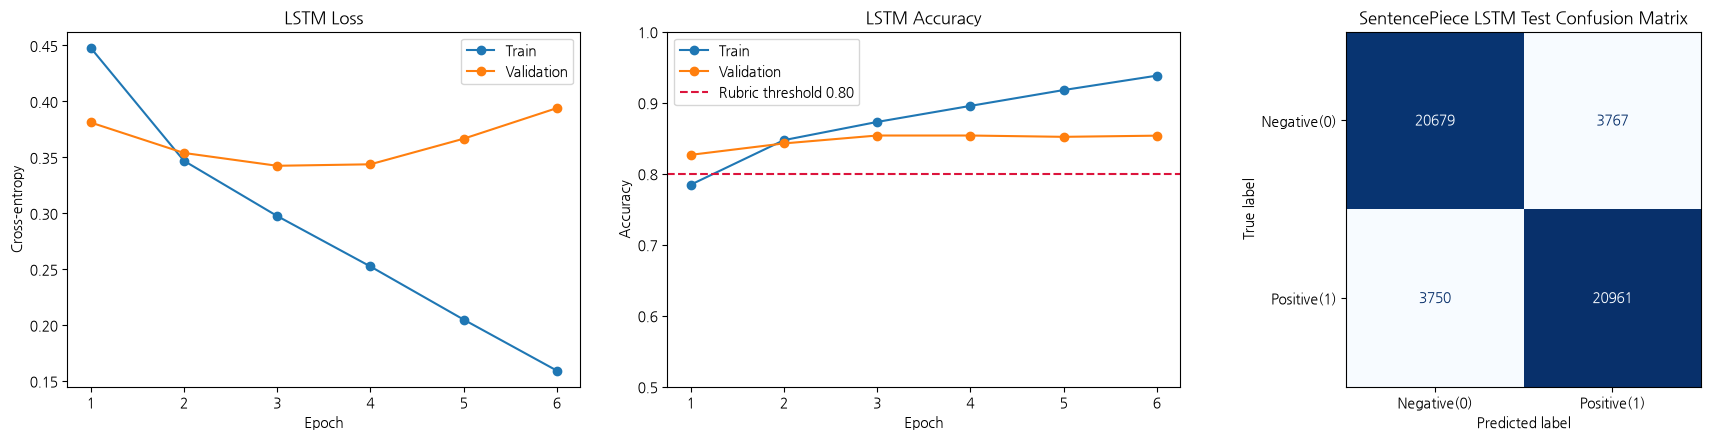

              precision    recall  f1-score   support

    negative     0.8465    0.8459    0.8462     24446
    positive     0.8477    0.8482    0.8480     24711

    accuracy                         0.8471     49157
   macro avg     0.8471    0.8471    0.8471     49157
weighted avg     0.8471    0.8471    0.8471     49157



In [53]:
# 데이터 시각화 
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

axes[0].plot(history["epoch"], history["train_loss"], marker="o", label="Train")
axes[0].plot(history["epoch"], history["valid_loss"], marker="o", label="Validation")
axes[0].set_title("LSTM Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-entropy")
axes[0].legend()

axes[1].plot(history["epoch"], history["train_acc"], marker="o", label="Train")
axes[1].plot(history["epoch"], history["valid_acc"], marker="o", label="Validation")
axes[1].axhline(0.80, color="crimson", linestyle="--", label=f'Rubric threshold {CONFIG["rubric_accuracy"]:.2f}')
axes[1].set_ylim(0.5, 1.0)
axes[1].set_title("LSTM Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

ConfusionMatrixDisplay(
    confusion_matrix(test_targets, test_predictions),
    display_labels=["Negative(0)", "Positive(1)"],
).plot(ax=axes[2], colorbar=False, cmap="Blues")
axes[2].set_title("SentencePiece LSTM Test Confusion Matrix")
plt.tight_layout()
plt.show()

print(classification_report(test_targets, test_predictions, target_names=["negative", "positive"], digits=4))


#### SentencePiece 옵션별 성능 비교 실험

```
# 다각도 비교분석 실험
# korean_spm.model은 SentencePiece 사용 흐름을 보여 주기 위한 모델
# 동일한 train_df 리뷰만으로 새로 학습
# 모든 옵션은 같은 train/validation/test 분할, LSTM 구조, 시드, epoch 수, 최대 시퀀스 길이, optimizer 조건을 사용
```
| 비교 옵션 | 조작 변수 | 통제 변수 | 분석 지표 |
| --- | --- | --- | --- |
| `unigram_8000` | unigram, 8,000 vocab | 데이터 분할·BiLSTM·학습률·epoch·max length | test accuracy, macro F1, token 길이, 학습 시간 |
| `bpe_8000` | BPE, 8,000 vocab | 동일 | test accuracy, macro F1, token 길이, 학습 시간 |
| `unigram_4000` | unigram, 4,000 vocab | 동일 | test accuracy, macro F1, token 길이, 학습 시간 |

> **누수 방지:** SentencePiece 모델은 train split만으로 학습하며 validation/test 리뷰는 성능 측정에만 사용


In [54]:
# 비교 실험용 SentencePiece 모델 학습과 토큰 통계
# CONFIG["comparison_options"]만 수정하면 비교할 옵션 변경 가능
import time
from sklearn.metrics import f1_score

def set_experiment_seed(seed: int) -> None:
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def train_comparison_tokenizer(option: dict) -> tuple:
    """
    train split만 이용해 옵션별 SentencePiece 모델을 학습
    """
    name = option["name"]
    prefix = Path(r"C:\Users\eaglesjo\work\sentiment_classification\data") / f"comparison_{name}"
    corpus_path = prefix.with_suffix(".train.txt")
    model_path = prefix.with_suffix(".model")
    vocab_path = prefix.with_suffix(".vocab")
    corpus_path.write_text("\n".join(train_df["document"].tolist()) + "\n", encoding="utf-8")

    if CONFIG["comparison_force_retrain"] or not model_path.exists():
        spm.SentencePieceTrainer.train(
            input=str(corpus_path),
            model_prefix=str(prefix),
            vocab_size=option["vocab_size"],
            model_type=option["model_type"],
            character_coverage=0.9995,
            hard_vocab_limit=False,
        )
    return spm.SentencePieceProcessor(model_file=str(model_path)), model_path, vocab_path

def tokenizer_length_statistics(processor) -> dict:
    lengths = train_df["document"].map(lambda text: len(processor.EncodeAsIds(text)))
    return {
        "actual_vocab_size": processor.get_piece_size(),
        "avg_tokens_per_review": float(lengths.mean()),
        "median_tokens_per_review": float(lengths.median()),
        "p95_tokens_per_review": float(lengths.quantile(0.95)),
    }

print("비교 옵션:")
for option in CONFIG["comparison_options"]:
    print(option)

비교 옵션:
{'name': 'unigram_8000', 'model_type': 'unigram', 'vocab_size': 8000}
{'name': 'bpe_8000', 'model_type': 'bpe', 'vocab_size': 8000}
{'name': 'unigram_4000', 'model_type': 'unigram', 'vocab_size': 4000}


In [55]:
# 옵션별 토큰 ID용 Dataset·LSTM·학습 함수
# 동일한 데이터 분할과 CONFIG를 사용하므로 토크나이저 옵션만 성능 차이의 핵심 변수
class ComparisonDataset(Dataset):
    def __init__(self, frame: pd.DataFrame, processor, max_length: int):
        self.labels = frame["label"].astype(int).tolist()
        self.sequences = [
            processor.EncodeAsIds(text)[:max_length] or [processor.unk_id()]
            for text in frame["document"]
        ]

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        return (
            torch.tensor(self.sequences[index], dtype=torch.long),
            torch.tensor(self.labels[index], dtype=torch.long),
        )

def make_comparison_loaders(processor, pad_id: int):
    def collate(batch):
        sequences, labels = zip(*batch)
        lengths = torch.tensor([len(sequence) for sequence in sequences], dtype=torch.long)
        padded = pad_sequence(sequences, batch_first=True, padding_value=pad_id)
        return padded, lengths, torch.stack(labels)

    frames = {"train": train_df, "valid": valid_df, "test": test_df}
    return {
        split: DataLoader(
            ComparisonDataset(frame, processor, CONFIG["max_length"]),
            batch_size=CONFIG["batch_size"],
            shuffle=(split == "train"),
            num_workers=0,
            pin_memory=(DEVICE.type == "cuda"),
            collate_fn=collate,
        )
        for split, frame in frames.items()
    }

class ComparisonBiLSTM(nn.Module):
    def __init__(self, vocab_size: int, pad_id: int):
        super().__init__()
        self.embedding = nn.Embedding(
            vocab_size, CONFIG["embedding_dim"], padding_idx=pad_id
        )
        self.lstm = nn.LSTM(
            CONFIG["embedding_dim"], CONFIG["hidden_dim"],
            batch_first=True, bidirectional=True,
        )
        self.classifier = nn.Sequential(
            nn.Dropout(CONFIG["dropout"]),
            nn.Linear(CONFIG["hidden_dim"] * 2, 2),
        )

    def forward(self, input_ids, lengths):
        embedded = self.embedding(input_ids)
        packed = pack_padded_sequence(
            embedded, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        _, (hidden, _) = self.lstm(packed)
        return self.classifier(torch.cat((hidden[-2], hidden[-1]), dim=1))

def evaluate_comparison_model(model, loader, criterion):
    model.eval()
    loss_sum, count = 0.0, 0
    targets, predictions = [], []
    with torch.no_grad():
        for input_ids, lengths, labels in loader:
            input_ids = input_ids.to(DEVICE)
            lengths = lengths.to(DEVICE)
            labels = labels.to(DEVICE)
            logits = model(input_ids, lengths)
            loss_sum += criterion(logits, labels).item() * len(labels)
            count += len(labels)
            targets.extend(labels.cpu().tolist())
            predictions.extend(logits.argmax(dim=1).cpu().tolist())
    return loss_sum / count, accuracy_score(targets, predictions), f1_score(targets, predictions, average="macro"), targets, predictions

def fit_tokenizer_option(option: dict, processor):
    """
    동일한 LSTM 조건에서 한 토크나이저 옵션을 학습·평가
    """
    set_experiment_seed(CONFIG["seed"])
    pad_id = processor.get_piece_size()  # unk_id=0과 충돌하지 않는 전용 pad
    loaders = make_comparison_loaders(processor, pad_id)
    model = ComparisonBiLSTM(processor.get_piece_size() + 1, pad_id).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=CONFIG["learning_rate"],
        weight_decay=CONFIG["weight_decay"],
    )
    history = {"epoch": [], "train_loss": [], "valid_loss": [], "train_accuracy": [], "valid_accuracy": []}
    best_state, best_valid_accuracy, wait = None, -1.0, 0
    started_at = time.perf_counter()

    for epoch in range(1, CONFIG["comparison_epochs"] + 1):
        model.train()
        loss_sum, train_targets, train_predictions = 0.0, [], []
        for input_ids, lengths, labels in loaders["train"]:
            input_ids = input_ids.to(DEVICE)
            lengths = lengths.to(DEVICE)
            labels = labels.to(DEVICE)
            optimizer.zero_grad()
            logits = model(input_ids, lengths)
            loss = criterion(logits, labels)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), CONFIG["gradient_clip_norm"])
            optimizer.step()
            loss_sum += loss.item() * len(labels)
            train_targets.extend(labels.detach().cpu().tolist())
            train_predictions.extend(logits.argmax(dim=1).detach().cpu().tolist())

        valid_loss, valid_accuracy, _, _, _ = evaluate_comparison_model(model, loaders["valid"], criterion)
        train_accuracy = accuracy_score(train_targets, train_predictions)
        history["epoch"].append(epoch)
        history["train_loss"].append(loss_sum / len(loaders["train"].dataset))
        history["valid_loss"].append(valid_loss)
        history["train_accuracy"].append(train_accuracy)
        history["valid_accuracy"].append(valid_accuracy)
        print(f"[{option['name']}] epoch={epoch:02d} train_accuracy={train_accuracy:.4f} valid_accuracy={valid_accuracy:.4f}")

        if valid_accuracy > best_valid_accuracy:
            best_valid_accuracy = valid_accuracy
            best_state = copy.deepcopy({key: value.detach().cpu() for key, value in model.state_dict().items()})
            wait = 0
        else:
            wait += 1
            if wait >= CONFIG["patience"]:
                print(f"[{option['name']}] early stopping")
                break

    train_seconds = time.perf_counter() - started_at
    model.load_state_dict(best_state)
    model.to(DEVICE)
    test_loss, test_accuracy, test_macro_f1, _, _ = evaluate_comparison_model(model, loaders["test"], criterion)
    return pd.DataFrame(history), {
        **option,
        "actual_vocab_size": processor.get_piece_size(),
        "best_validation_accuracy": best_valid_accuracy,
        "test_accuracy": test_accuracy,
        "test_macro_f1": test_macro_f1,
        "test_loss": test_loss,
        "train_seconds": train_seconds,
    }

In [56]:
# unigram·BPE·어휘 크기 옵션의 공정 비교 실행
if not CONFIG["run_tokenizer_comparison"]:
    print("CONFIG['run_tokenizer_comparison']=False이므로 비교 실험을 건너뜁니다.")
else:
    comparison_rows = []
    comparison_histories = {}

    for option in CONFIG["comparison_options"]:
        print("\n" + "=" * 80)
        print(f"비교 실행: {option['name']} | type={option['model_type']} | vocab={option['vocab_size']}")
        processor, model_path, vocab_path = train_comparison_tokenizer(option)
        history, metrics = fit_tokenizer_option(option, processor)
        metrics.update(tokenizer_length_statistics(processor))
        comparison_rows.append(metrics)
        comparison_histories[option["name"]] = history

    comparison_df = pd.DataFrame(comparison_rows).sort_values(
        ["test_accuracy", "test_macro_f1"], ascending=False
    ).reset_index(drop=True)
    comparison_df.to_csv(
        Path(r"C:\Users\eaglesjo\work\sentiment_classification\data") / "sentencepiece_tokenizer_comparison.csv",
        index=False, encoding="utf-8-sig",
    )
    print("\n[토크나이저 비교 결과]")
    display(comparison_df.style.format({
        "best_validation_accuracy": "{:.4f}",
        "test_accuracy": "{:.4f}",
        "test_macro_f1": "{:.4f}",
        "test_loss": "{:.4f}",
        "avg_tokens_per_review": "{:.2f}",
        "median_tokens_per_review": "{:.2f}",
        "p95_tokens_per_review": "{:.2f}",
        "train_seconds": "{:.1f}",
    }))


비교 실행: unigram_8000 | type=unigram | vocab=8000
[unigram_8000] epoch=01 train_accuracy=0.7689 valid_accuracy=0.8291
[unigram_8000] epoch=02 train_accuracy=0.8578 valid_accuracy=0.8466
[unigram_8000] epoch=03 train_accuracy=0.8854 valid_accuracy=0.8501
[unigram_8000] epoch=04 train_accuracy=0.9090 valid_accuracy=0.8522
[unigram_8000] epoch=05 train_accuracy=0.9338 valid_accuracy=0.8449
[unigram_8000] epoch=06 train_accuracy=0.9555 valid_accuracy=0.8466
[unigram_8000] epoch=07 train_accuracy=0.9713 valid_accuracy=0.8452
[unigram_8000] early stopping

비교 실행: bpe_8000 | type=bpe | vocab=8000
[bpe_8000] epoch=01 train_accuracy=0.7709 valid_accuracy=0.8382
[bpe_8000] epoch=02 train_accuracy=0.8577 valid_accuracy=0.8512
[bpe_8000] epoch=03 train_accuracy=0.8859 valid_accuracy=0.8472
[bpe_8000] epoch=04 train_accuracy=0.9110 valid_accuracy=0.8460
[bpe_8000] epoch=05 train_accuracy=0.9374 valid_accuracy=0.8439
[bpe_8000] early stopping

비교 실행: unigram_4000 | type=unigram | vocab=4000
[unigram_

,name,model_type,vocab_size,actual_vocab_size,best_validation_accuracy,test_accuracy,test_macro_f1,test_loss,train_seconds,avg_tokens_per_review,median_tokens_per_review,p95_tokens_per_review
0,unigram_4000,unigram,4000,4000,0.8530,0.8517,0.8517,0.3701,82.4,20.21,15.00,61.00
1,unigram_8000,unigram,8000,8000,0.8522,0.8482,0.8482,0.3663,81.8,17.33,13.00,52.00
2,bpe_8000,bpe,8000,8000,0.8512,0.8457,0.8457,0.3495,57.9,17.00,13.00,51.00


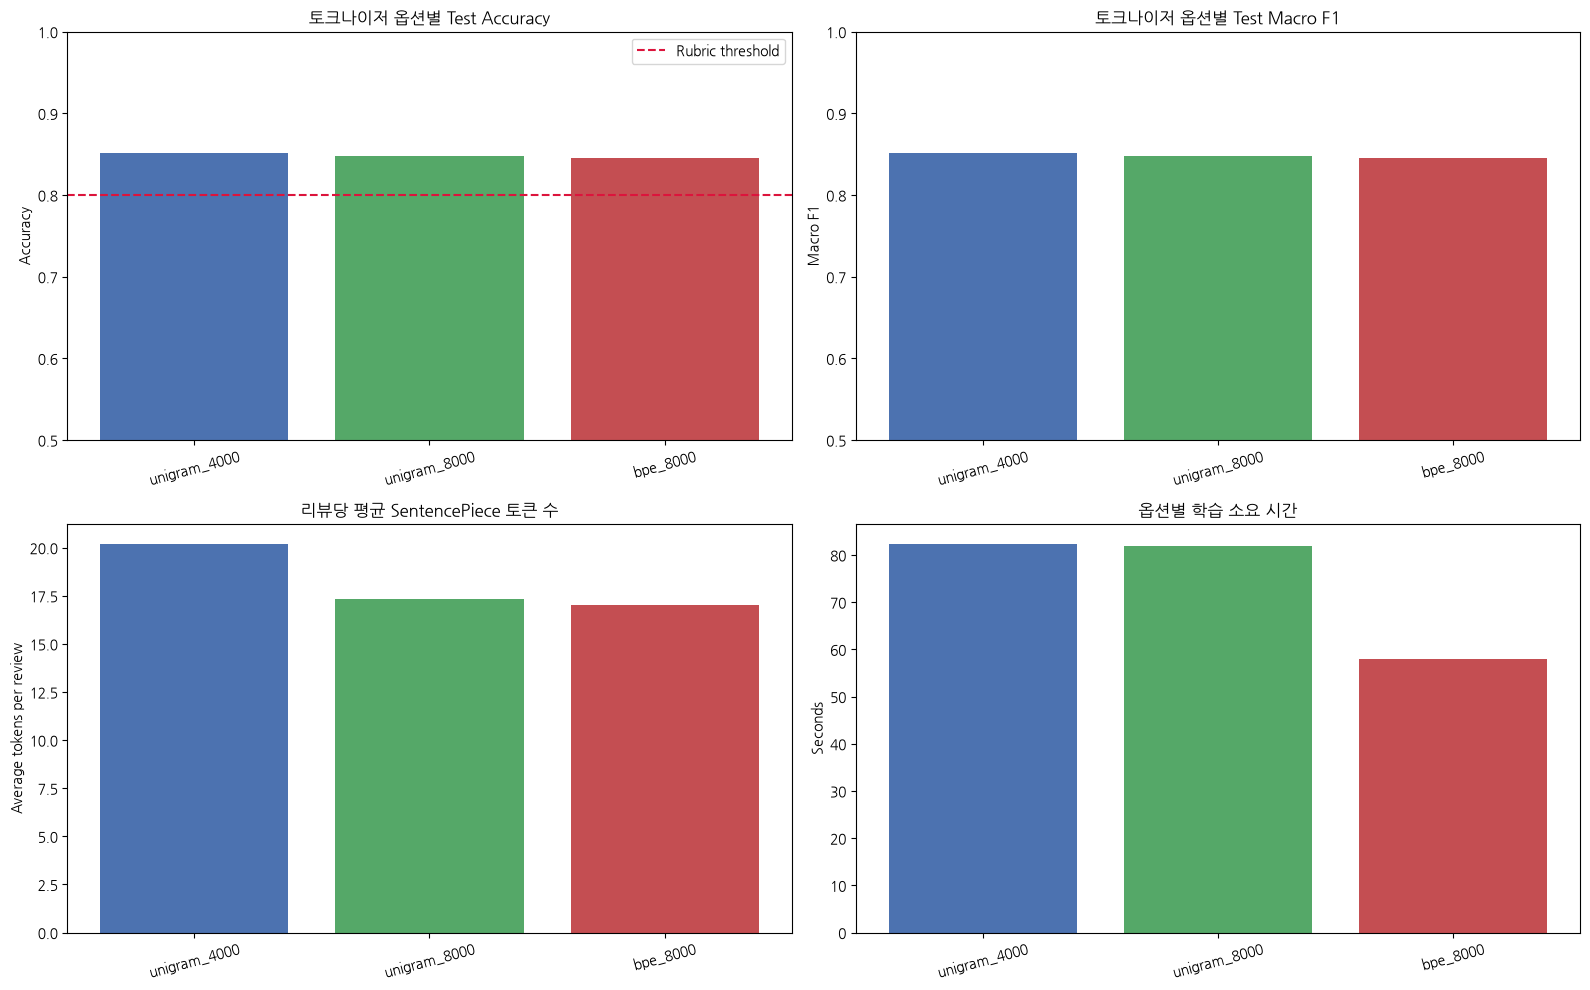

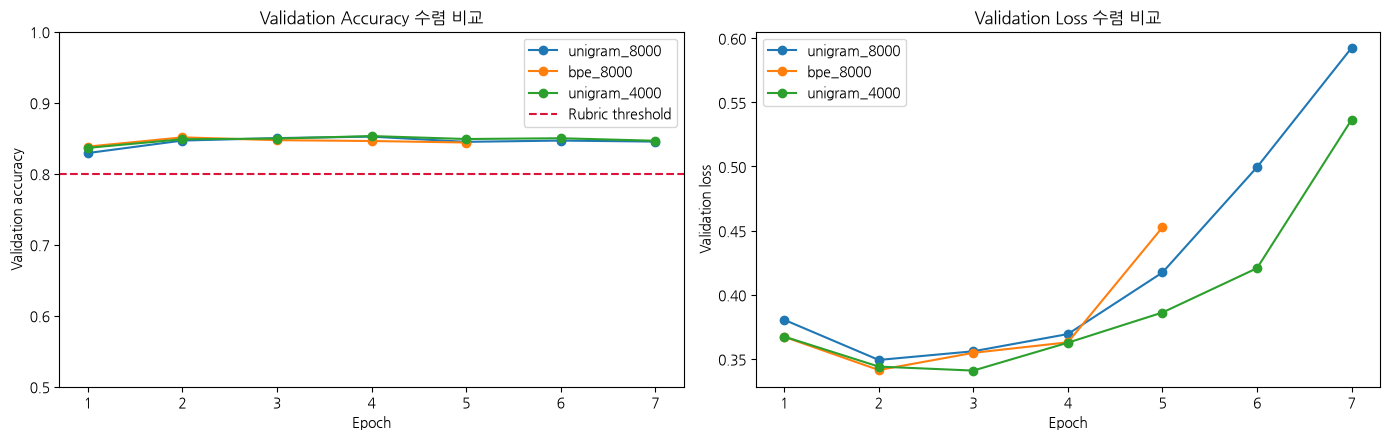

In [59]:
# 비교 결과 시각화 — 성능·토큰 효율·학습 비용·수렴
if CONFIG["run_tokenizer_comparison"]:
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    labels = comparison_df["name"]
    colors = ["#4C72B0", "#55A868", "#C44E52"][:len(labels)]

    axes[0, 0].bar(labels, comparison_df["test_accuracy"], color=colors)
    axes[0, 0].axhline(CONFIG["rubric_accuracy"], color="crimson", linestyle="--", label="Rubric threshold")
    axes[0, 0].set_ylim(0.5, 1.0)
    axes[0, 0].set_title("토크나이저 옵션별 Test Accuracy")
    axes[0, 0].set_ylabel("Accuracy")
    axes[0, 0].tick_params(axis="x", rotation=15)
    axes[0, 0].legend()

    axes[0, 1].bar(labels, comparison_df["test_macro_f1"], color=colors)
    axes[0, 1].set_ylim(0.5, 1.0)
    axes[0, 1].set_title("토크나이저 옵션별 Test Macro F1")
    axes[0, 1].set_ylabel("Macro F1")
    axes[0, 1].tick_params(axis="x", rotation=15)

    axes[1, 0].bar(labels, comparison_df["avg_tokens_per_review"], color=colors)
    axes[1, 0].set_title("리뷰당 평균 SentencePiece 토큰 수")
    axes[1, 0].set_ylabel("Average tokens per review")
    axes[1, 0].tick_params(axis="x", rotation=15)

    axes[1, 1].bar(labels, comparison_df["train_seconds"], color=colors)
    axes[1, 1].set_title("옵션별 학습 소요 시간")
    axes[1, 1].set_ylabel("Seconds")
    axes[1, 1].tick_params(axis="x", rotation=15)
    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
    for name, history in comparison_histories.items():
        axes[0].plot(history["epoch"], history["valid_accuracy"], marker="o", label=name)
        axes[1].plot(history["epoch"], history["valid_loss"], marker="o", label=name)
    axes[0].axhline(CONFIG["rubric_accuracy"], color="crimson", linestyle="--", label="Rubric threshold")
    axes[0].set_title("Validation Accuracy 수렴 비교")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Validation accuracy")
    axes[0].set_ylim(0.5, 1.0)
    axes[0].legend()
    axes[1].set_title("Validation Loss 수렴 비교")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Validation loss")
    axes[1].legend()
    plt.tight_layout()
    plt.show()


In [61]:
# 비교 분석 자동 요약과 해석
if CONFIG["run_tokenizer_comparison"]:
    best = comparison_df.iloc[0]
    baseline_name = CONFIG["comparison_options"][0]["name"]
    baseline = comparison_df.loc[comparison_df["name"] == baseline_name].iloc[0]
    accuracy_gap = best["test_accuracy"] - baseline["test_accuracy"]
    token_gap = best["avg_tokens_per_review"] - baseline["avg_tokens_per_review"]

    conclusion = f'''[비교 실험 결론]
- 공정성: 모든 옵션은 동일한 train/validation/test 분할, BiLSTM 구조, 학습률, max_length, epoch와 seed를 사용했다.
- 최고 성능: {best['name']}이 test accuracy={best['test_accuracy']:.4f}, macro F1={best['test_macro_f1']:.4f}로 가장 높았다.
- 기준 모델 대비: unigram_8000 대비 accuracy 차이는 {accuracy_gap:+.4f}, 평균 토큰 수 차이는 {token_gap:+.2f}개/리뷰이다.
- 효율성: {best['name']}의 평균 토큰 수는 {best['avg_tokens_per_review']:.2f}, 학습 시간은 {best['train_seconds']:.1f}초였다.
- 해석: accuracy·macro F1뿐 아니라 토큰 길이(시퀀스 계산량)와 학습 시간까지 함께 고려해 토크나이저를 선택해야 한다.
'''
    print(conclusion)
    (Path(r"C:\Users\eaglesjo\work\sentiment_classification\data") / "sentencepiece_comparison_summary.txt").write_text(conclusion, encoding="utf-8")

    print("\n[제출용 문장 템플릿]")
    print(
        f"동일한 NSMC 데이터 분할과 BiLSTM 학습 조건에서 SentencePiece unigram(8,000), "
        f"BPE(8,000), unigram(4,000)을 비교하였다. 최고 성능은 {best['name']}으로 "
        f"test accuracy {best['test_accuracy']:.4f}, macro F1 {best['test_macro_f1']:.4f}를 기록했다. "
        f"또한 평균 토큰 수 {best['avg_tokens_per_review']:.2f}와 학습 시간 {best['train_seconds']:.1f}초를 함께 비교하여, "
        "정확도뿐 아니라 토큰화 효율과 계산 비용을 포함한 다각도 평가를 수행하였다."
    )

[비교 실험 결론]
- 공정성: 모든 옵션은 동일한 train/validation/test 분할, BiLSTM 구조, 학습률, max_length, epoch와 seed를 사용했다.
- 최고 성능: unigram_4000이 test accuracy=0.8517, macro F1=0.8517로 가장 높았다.
- 기준 모델 대비: unigram_8000 대비 accuracy 차이는 +0.0035, 평균 토큰 수 차이는 +2.88개/리뷰이다.
- 효율성: unigram_4000의 평균 토큰 수는 20.21, 학습 시간은 82.4초였다.
- 해석: accuracy·macro F1뿐 아니라 토큰 길이(시퀀스 계산량)와 학습 시간까지 함께 고려해 토크나이저를 선택해야 한다.


[제출용 문장 템플릿]
동일한 NSMC 데이터 분할과 BiLSTM 학습 조건에서 SentencePiece unigram(8,000), BPE(8,000), unigram(4,000)을 비교하였다. 최고 성능은 unigram_4000으로 test accuracy 0.8517, macro F1 0.8517를 기록했다. 또한 평균 토큰 수 20.21와 학습 시간 82.4초를 함께 비교하여, 정확도뿐 아니라 토큰화 효율과 계산 비용을 포함한 다각도 평가를 수행하였다.
